<a href="http://landlab.github.io"><img style="float: left" src="https://raw.githubusercontent.com/landlab/tutorials/release/landlab_header.png"></a>

# <span style="color:red">Team ESPIn! Let's make a coupled channel-hillslope landscape evolution model!</span>

This tutorial illustrates the `FastscapeEroder` channel evolver component, which requires the `FlowAccumulator` component. After running an example model with just channels, you will be challenged to add hillslopes to the model. 

Along the way you will be exposed to different plotting tools available in Landlab.

You should already be familiar with Landlab grids, fields, and the `LinearDiffuser` component before running this notebook.

Last edited for ESPIn 2026.

##  The Fastscape Eroder component
 
This component calculates fluvial incision into the landscape using the stream power model. It uses the Fastscape numerical algorithm for calculating incision. 

Fluvial incision, *I* (generally in m/yr), is calculated as:


$$I = K_\text{sp} A^{m_{sp}} S^{n_{sp}} $$

- $K_{sp}$ is the erodibility coefficient on fluvial incision, which is thought to be positively correlated with climate wetness, or storminess (this is hard to quantify) and to be negatively correlated with rock strength (again, rock strength is hard to quantify). 
- $m_{sp}$ and $n_{sp}$ are positive exponents, usually thought to have a ratio, $m_{sp}/n_{sp} \approx 0.5$. 
- $A$ is drainage area, which is a proxy for discharge. To calculate drainage area we need to route flow across the landscape. That is done using the `FlowAccumulator` component.
- $S$ is the topographic gradient of slope of steepest descent ($-\frac{dz}{dx}$) where $x$ is horizontal distance (positive in the downslope direction) and $z$ is elevation. (If slope is negative there is no fluvial erosion.) 

For an overview of the stream power equation, see: 

- Whipple and Tucker, 1999, Dynamics of the stream-power river incision model: Implications for height limits of mountain ranges, landscape response timescales, and research needs, Journal of Geophysical Research.


For a description of the Fastscape algorithm see:

- Braun and Willett, 2013, A very efficient O(n) implicit and parallel method to solve the stream power equation governing fluvial incision and landscape evolution, Geomorphology.

### Import statements

Code block 0.1 should be run first and does not need to be rerun 
during continual use of this notebook.

In [1]:
# Code block 0.1

# Import some non-landlab libraries
import numpy as np
import matplotlib as mpl

# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import FastscapeEroder, FlowAccumulator, LinearDiffuser, ChannelProfiler

## <span style="color:green">Example with fluvial erosion only</span>

### Instantiate a grid

In [2]:
num_rows = 100  # number of grid rows
num_cols = 200  # number of grid columns
dxy = 50  # resolution of raster cell [m], or node horizontal and vertical spacing

# Create the grid
mg = RasterModelGrid((num_rows, num_cols), dxy)

### Initialize and visualize the topography

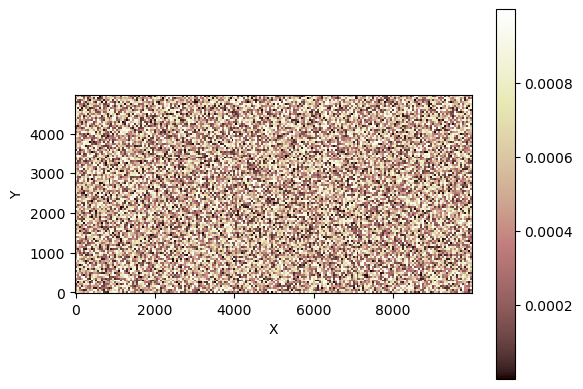

In [3]:
# Make some noise to add to the initial topography.
# This is not necessary, but it is a trick to make networks look more `real`

np.random.seed(0)  
mg_noise = np.random.rand(mg.number_of_nodes) / 1000.0  # intial noise on elevation grid

# Set-up the elevation field on the grid
zr = mg.add_zeros("topographic__elevation", at="node")
zr += mg_noise

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

### Set parameters and create an instance of the flow accumulation and fluvial erosion components

In [4]:
# Stream power parameters
K_sp = 1.0e-5  # erodibility, units depend on m and n exponents
m_sp = 0.5  # exponent on drainage area
n_sp = 1.0  # exponent on slope

# Create the flow accumulation and fluvial incision components
fr = FlowAccumulator(mg, flow_director="D8")
fs = FastscapeEroder(mg, m_sp=m_sp, n_sp=n_sp, K_sp=K_sp)

### Want to learn more about the FastscapeEroder parameters?

Also, don't forget about the `shift` + `tab` trick!

In [5]:
print(FastscapeEroder.__init__.__doc__)

Initialize the Fastscape stream power component. Note: a timestep,
dt, can no longer be supplied to this component through the input file.
It must instead be passed directly to the run method.

Parameters
----------
grid : ModelGrid
    A grid.
K_sp : float, array, or field name
    K in the stream power equation (units vary with other parameters).
m_sp : float, optional
    m in the stream power equation (power on drainage area).
n_sp : float, optional
    n in the stream power equation (power on slope).
threshold_sp : float, array, or field name
    Erosion threshold in the stream power equation.
discharge_field : float, field name, or array, optional
    Discharge [L^2/T]. The default is to use the grid field
    'drainage_area'. To use custom spatially/temporally varying
    rainfall, use 'water__unit_flux_in' to specify water input to the
    FlowAccumulator and use "surface_water__discharge" for this
    keyword argument.
erode_flooded_nodes : bool (optional)
    Whether erosion 

### Set model time and uplift parameters

In [6]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 1e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 0.001  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]

### Run the fluvial model

In [7]:
for i in range(nsteps):
    zr[mg.core_nodes] += uplift_length  # uplift the landscape
    fr.run_one_step()  # route flow
    fs.run_one_step(dt)  # fluvial incision
    modeled_time += dt  # update time keeper
    
    # sometimes it's nice to see that the model is progressing, especially if it's slow
    if int(modeled_time % 1e5) == 0:
        print("model run time",modeled_time)
        print("maximum elevation",max(mg.at_node["topographic__elevation"][mg.core_nodes]))

model run time 100000
maximum elevation 100.00064286107067
model run time 200000
maximum elevation 200.00037499917428
model run time 300000
maximum elevation 300.0002667594955
model run time 400000
maximum elevation 400.0001949156407
model run time 500000
maximum elevation 499.99997121814283
model run time 600000
maximum elevation 599.8862137321979
model run time 700000
maximum elevation 695.6052605876953
model run time 800000
maximum elevation 768.4743917599553
model run time 900000
maximum elevation 803.0887763043972
model run time 1000000
maximum elevation 807.7363016289605


### Visualize the topography

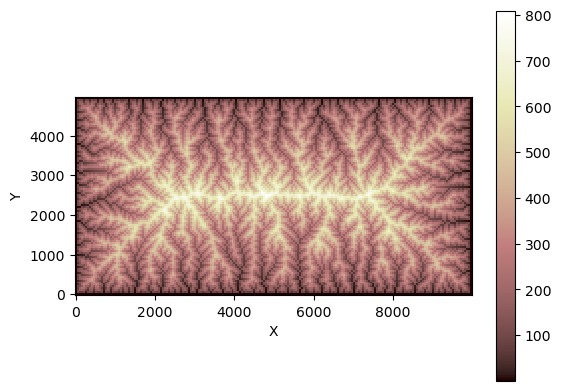

In [8]:
imshow_grid(mg, "topographic__elevation")

### Another way to visualize the topography

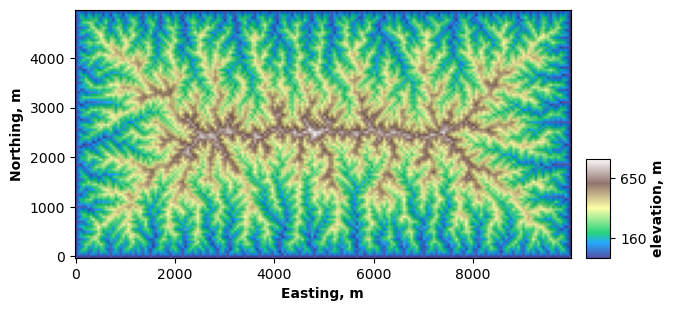

In [9]:
# Elevation map draped over shaded relief
# Don't get thrown off by all the parameter values.
# They are included because this function makes beautiful visualizations,
# and it can be helpful to `see` different aspects of the landscape by changing
# the parameters.

cmap = mpl.colormaps["terrain"]
plot_type = "Drape1"
#plot_type = "DEM"
drape1 = "topographic__elevation"
ax = imshowhs_grid(
    mg,
    "topographic__elevation",
    plot_type=plot_type,
    drape1=drape1,
    alpha=0.85,
#    altdeg=55.,
#    azdeg=180,
    cmap=cmap,
    grid_units=("m", "m"),
    default_fontsize=10,
    cbar_tick_size=10,
    var_name="elevation, m",
    cbar_width="100%",
    cbar_or="vertical",
    bbox_to_anchor=[1.03, 0.0, 0.05, 8],
    colorbar_label_y=3,
    #colorbar_label_x=-100,
    ticks_km=False,
)

### A drainage area map

Because drainage area varies by orders of magnitude, it is often easier to visualize on a log scale. Plotting drainage area is one way to visualize the networks. It is also helpful to see if the model has developed continuous networks.

Text(0.5, 1.0, 'log10 of drainage area, time = 1000000')

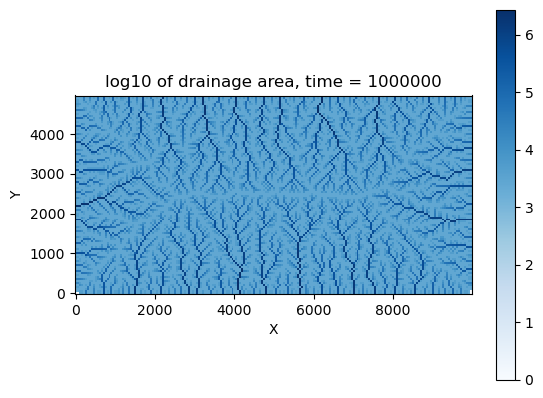

In [10]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

### Plot some channel profiles

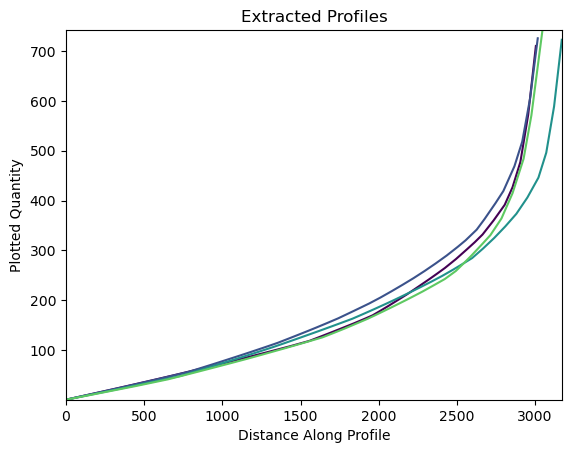

In [11]:
# Instantiate the ChannelProfiler component.
# The drainage area map can be helpful for deciding the minimum channel threshold.
prf = ChannelProfiler(mg, number_of_watersheds=4, minimum_channel_threshold=1e2)

# Run the component and plot the profiles
prf.run_one_step()
prf.plot_profiles()

### Where on the landscape are these channels?

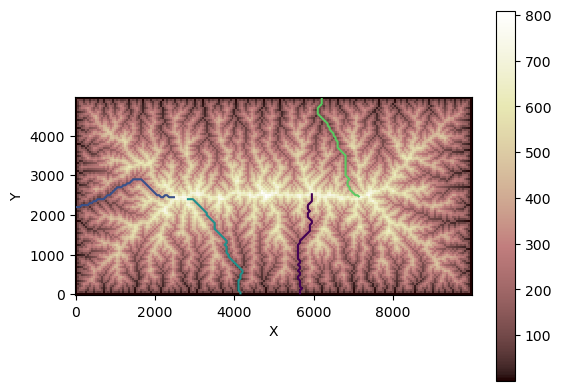

In [12]:
# Plot the channels on map
prf.plot_profiles_in_map_view()

### Got all that? Now...

# <span style="color:red">Here's your main challenge!</span>

**Add linear diffusion to this landscape evolution model**, so that now you will have hillslopes and channels. You can either add it to the existing code, or create a new model code below that includes diffusion. You can refer back to the first Landlab notebook to see how the `LinearDiffuser` works, or access the documentation, or use some of the tricks you know to get information on a component.

Some general info:
- Diffusion may slow down compute time.
- Sometimes diffusion requires a shorter time step for stability than stream power erosion.
- If channels become discontinuous, they are likely getting clogged with sediment from the hillslopes. This usually goes away if you reduce the time step. This is easiest to spot on the drainage area map, and will result in short channels using the channel profiler

## <span style="color:red">Want a few more challenges?</span>

- Varying the stream power coefficient and/or the diffusivity will impact the drainage density. Can you see that in the maps you make? Try calculating the drainage density using [this component](https://landlab.csdms.io/generated/api/landlab.components.drainage_density.drainage_density.html#landlab.components.drainage_density.drainage_density.DrainageDensity). There is also a tutorial available [here](https://landlab.csdms.io/tutorials/terrain_analysis/drainage_density/drainage_density.html).
- If you are familiar with [channel steepness](https://landlab.csdms.io/tutorials/terrain_analysis/steepness_finder/steepness_finder.html) or [chi](https://landlab.csdms.io/tutorials/terrain_analysis/chi_finder/chi_finder.html), try making maps or profiles of these quantities.
- What happens if you add a normal fault to the landscape? Check out [this tutorial](https://landlab.csdms.io/tutorials/normal_fault/normal_fault_component_tutorial.html) for help.
- Try changing the boundary conditions so that flow can only exit the grid on the south side. Hint: Code for this was included in the first Landlab notebook. 